In [1]:
from sklearn.datasets import load_iris
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

In [26]:
iris = load_iris()
_global_var_data_x = torch.tensor(iris.data, dtype=torch.float32)
_global_var_target = torch.tensor(iris.target, dtype=torch.int64)

class IrisDataset(data.Dataset):
    def __init__(self):
        self.data = _global_var_data_x # тензор размерностью (150, 4), тип float32
        self.target = _global_var_target # тензор размерностью (150, ), тип int64 (long)

        self.length = len(self.data) # размер выборки
        self.categories = ['setosa' 'versicolor' 'virginica'] # названия классов
        self.features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

    def __getitem__(self, item):
        # возврат образа по индексу item в виде кортежа: (данные, целевое значение)
        return self.data[item], self.target[item]

    def __len__(self):
        # возврат размера выборки
        return self.length


class IrisClassModel(nn.Module):
    def __init__(self, in_features=4, out_features=3):
        super().__init__()
        # модель нейронной сети из двух полносвязных слоев:
        # 1-й слой: число входов in_features, число нейронов 16
        self.layer1 = nn.Linear(in_features, 16)
        # 2-й слой: число нейронов out_features
        self.layer2 = nn.Linear(16, out_features)

    def forward(self, x):
        # тензор x пропускается через 1-й слой
        # через функцию активации torch.relu()
        y = self.layer1(x).relu()
        # через второй слой
        y = self.layer2(y)
        # полученный (вычисленный) тензор возвращается
        return y


torch.manual_seed(11)

# создать модель IrisClassModel с числом входов 4 и числом выходов 3
model = IrisClassModel(4, 3)

# перевести модель в режим обучения
model.train()

epochs = 10 # число эпох обучения
batch_size = 8 # размер батча
lr = 0.01

# создать объект класса IrisDataset
d_train = IrisDataset() 

# создать объект класса DataLoader с размером пакетов batch_size и перемешиванием образов выборки
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=lr) # создать оптимизатор Adam для обучения модели с шагом обучения 0.01
loss_func = nn.CrossEntropyLoss() # создать функцию потерь с помощью класса CrossEntropyLoss (используется при многоклассовой классификации)

for _e in range(epochs): # итерации по эпохам
    for x_train, y_train in train_data:
        predict = model(x_train) # вычислить прогноз модели для данных x_train
        loss = loss_func(predict, y_train) # вычислить значение функции потерь

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# перевести модель в режим эксплуатации
model.eval()
# выполнить прогноз модели по всем данным выборки
predict = model(d_train.data)
t_pred = predict.argmax(dim=1)
Q = torch.mean((t_pred == d_train.target).float()).item() # вычислить долю верных классификаций (сохранить, как вещественное число, а не тензор)
Q

0.9599999785423279

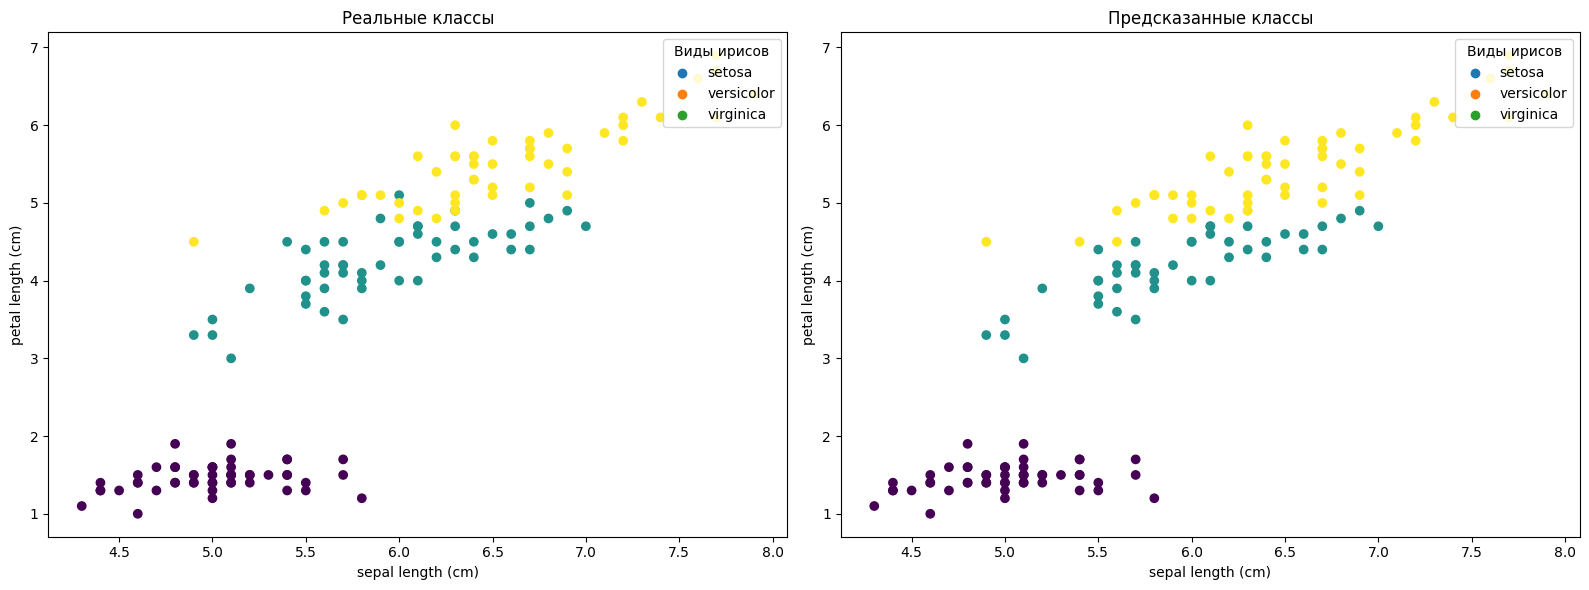

In [27]:
# График
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Ещё раз загрузим исходник, так проще
iris = load_iris()

# Две доски под графики
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Реальные классы
axs[0].scatter(iris.data[:, 0], iris.data[:, 2], c=iris.target)
axs[0].set_xlabel(iris.feature_names[0])  # Длина чашелистиков
axs[0].set_ylabel(iris.feature_names[2])  # Длина лепестков
axs[0].set_title("Реальные классы")
for i, target_name in enumerate(iris.target_names):
    axs[0].scatter([], [], label=target_name)
axs[0].legend(loc="upper right", title="Виды ирисов")

# График 2: Предсказанные классы
axs[1].scatter(iris.data[:, 0], iris.data[:, 2], c=t_pred)
axs[1].set_xlabel(iris.feature_names[0])  # Длина чашелистиков
axs[1].set_ylabel(iris.feature_names[2])  # Длина лепестков
axs[1].set_title("Предсказанные классы")
for i, target_name in enumerate(iris.target_names):
    axs[1].scatter([], [], label=target_name)
axs[1].legend(loc="upper right", title="Виды ирисов")

# Отображаем
plt.tight_layout()
plt.show()

In [29]:
from sklearn.datasets import load_wine
import torch


wine_data = load_wine()

# Признаки и целевые значения
_global_var_data_x = torch.tensor(wine_data.data, dtype=torch.float32)
_global_var_target = torch.tensor(wine_data.target, dtype=torch.int64)

# Размеры и типы
print("Размеры и типы:", _global_var_data_x.shape, _global_var_data_x.dtype, _global_var_target.shape, _global_var_target.dtype)

# Прочие характеристики
print("Количество классов: ", len(wine_data.target_names))
print("Названия классов: ", wine_data.target_names)
print("Названия признаков: ", wine_data.feature_names)

# Первые строки данных
print("Первые 5 строк признаков:\n", _global_var_data_x[:5])
print("Первые 5 целевых значений:\n", _global_var_target[:5])

Размеры и типы: torch.Size([178, 13]) torch.float32 torch.Size([178]) torch.int64
Количество классов:  3
Названия классов:  ['class_0' 'class_1' 'class_2']
Названия признаков:  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Первые 5 строк признаков:
 tensor([[1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
         3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
         1.0650e+03],
        [1.3200e+01, 1.7800e+00, 2.1400e+00, 1.1200e+01, 1.0000e+02, 2.6500e+00,
         2.7600e+00, 2.6000e-01, 1.2800e+00, 4.3800e+00, 1.0500e+00, 3.4000e+00,
         1.0500e+03],
        [1.3160e+01, 2.3600e+00, 2.6700e+00, 1.8600e+01, 1.0100e+02, 2.8000e+00,
         3.2400e+00, 3.0000e-01, 2.8100e+00, 5.6800e+00, 1.0300e+00, 3.1700e+00,
         1.1850e+03],
        [1.4370e+01, 1.9500e+00, 2

In [31]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim


class WineDataset(data.Dataset):
    def __init__(self):
        self.data = torch.tensor(_global_var_data_x, dtype=torch.float32) # тензор размерностью (178, 13), тип float32
        self.target = torch.tensor(_global_var_target, dtype=torch.int64) # тензор размерностью (178, ), тип int64 (long)

        self.length = len(self.data) # размер выборки
        self.categories = ['class_0', 'class_1', 'class_2'] # названия классов

    def __getitem__(self, item):
        # возврат образа по индексу item в виде кортежа: (данные, целевое значение)
        return self.data[item], self.target[item]

    def __len__(self):
        # возврат размера выборки
        return self.length


class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(13, 32)
        self.layer2 = nn.Linear(32, 16)
        self.layer3 = nn.Linear(16, 3)

    def forward(self, x):
        y = self.layer1(x).relu()
        y = self.layer2(y).relu()
        y = self.layer3(y)
        return y

# здесь продолжайте программу
model = Model()

model.train()

epochs = 20
batch_size = 16
lr = 0.01

d_train = WineDataset()
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=lr)
loss_func = nn.CrossEntropyLoss()

for _e in range(epochs):
    for x_train, y_train in train_data:
        predict = model(x_train)
        loss = loss_func(predict, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()

predict = model(d_train.data)
t_pred = predict.argmax(dim=1)
Q = torch.mean((t_pred == d_train.target).float()).item()
Q

C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_11928\2251453704.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(_global_var_data_x, dtype=torch.float32) # тензор размерностью (178, 13), тип float32
C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_11928\2251453704.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.target = torch.tensor(_global_var_target, dtype=torch.int64) # тензор размерностью (178, ), тип int64 (long)


0.9269663095474243

In [34]:
# @title Data
from sklearn.datasets import load_digits
import torch


digits = load_digits()

# Признаки и целевые значения
_global_var_data_x = torch.tensor(digits.data, dtype=torch.float32)
_global_var_target = torch.tensor(digits.target, dtype=torch.int64)

# Размеры и типы
print("Размеры и типы:", _global_var_data_x.shape, _global_var_data_x.dtype, _global_var_target.shape, _global_var_target.dtype)

# Прочие характеристики
print("Количество классов: ", len(digits.target_names))
print("Названия классов: ", digits.target_names)
print("Названия признаков: ", digits.feature_names)

# Первые строки данных
print("Первые 5 строк признаков:\n", _global_var_data_x[:5])
print("Первые 5 целевых значений:\n", _global_var_target[:5])

Размеры и типы: torch.Size([1797, 64]) torch.float32 torch.Size([1797]) torch.int64
Количество классов:  10
Названия классов:  [0 1 2 3 4 5 6 7 8 9]
Названия признаков:  ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7

In [35]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim


# здесь продолжайте программу
class Dataset(data.Dataset):
    def __init__(self):
        super().__init__()

        self.data = torch.tensor(_global_var_data_x, dtype=torch.float32)
        self.target = torch.tensor(_global_var_target, dtype=torch.int64)
        self.length = len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.target[index]
    
    def __len__(self):
        return self.length
    

class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(64, 32)
        self.layer2 = nn.Linear(32, 16)
        self.layer3 = nn.Linear(16, 10)

    def forward(self, x):
        y = self.layer1(x).relu()
        y = self.layer2(y).relu()
        y = self.layer3(y)
        return y

epochs = 10
batch_size = 12
lr = 0.01

d_train = Dataset()
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)

model = Model()

optimizer = optim.Adam(model.parameters(), lr=lr)
loss_func = nn.CrossEntropyLoss()

model.train()

for _e in range(epochs):
    for x_train, y_train in train_data:
        predict = model(x_train)
        loss = loss_func(predict, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

predict = model(d_train.data)
t_pred = predict.argmax(dim=1)
Q = torch.mean((t_pred == d_train.target).float()).item()
Q

C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_11928\1263630517.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(_global_var_data_x, dtype=torch.float32)
C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_11928\1263630517.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.target = torch.tensor(_global_var_target, dtype=torch.int64)


0.9660545587539673

In [40]:
import torch

t = torch.empty(128).fill_(13)
t2 = t.view(8, 16)
t3 = t.view(-1, 32)
t4 = t.reshape(2, 4, 16)
t.resize_(16, 4)

t[0, 0] = 5

print(t)
print(t4)

tensor([[ 5., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.],
        [13., 13., 13., 13.]])
tensor([[[ 5., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13.,
          13., 13.],
         [13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13.,
          13., 13.],
         [13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13.,
          13., 13.],
         [13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13.,
          13., 13.]],

        [[13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13.,
          13., 13.],
         [13

- torch.matmul() перемножение матриц или матрицы с вектором с эффектом транслирования

- torch.mm() перемножение матриц или матрицы с вектором без эффекта транслирования

- torch.bmm() перемножение матриц или матрицы с вектором независимо по батчу

- torch.dot() скалярное умножение векторов (и матрицы с вектором)

- torch.outer() внешнее умножение векторов